# Fase 4 — Deep Learning con Embeddings (CRISP-DM *Modeling* + *Evaluation*)
## Sistema Inteligente de Recomendación de Películas — MovieLens (OmniRec)

Notebook `04_DeepLearning_Embeddings.ipynb`. Continúa el **baseline clásico** del notebook `03_ML_Baseline_AutoML.ipynb` y lleva el modelado hacia **arquitecturas neuronales de filtrado colaborativo**.

### Objetivo y rigor experimental
El propósito **no** es "ganarle" al modelo clásico a toda costa, sino comparar de forma **justa y reproducible** la factorización matricial clásica contra el Deep Learning sobre el **mismo dataset y la misma partición**, y —fiel al nombre del notebook— **analizar los *embeddings* aprendidos**.

Decisiones metodológicas que corrigen los errores típicos de una comparación ingenua:

1. **Una sola partición train/val/test (70/15/15)** alimenta a *todos* los modelos. Nada de comparar números calculados sobre datasets o splits distintos.
2. **Filtrado *warm-start*** en val/test: solo usuarios y películas vistos en *train*. Así medimos capacidad de modelado y no el azar del cold-start (que penalizaría injustamente a las redes con *embeddings* no entrenados).
3. **Sesgos** (global + usuario + ítem) en los modelos neuronales — el ingrediente que hace fuerte al SVD.
4. **Salida acotada al rango real** de ratings `[0.5, 5.0]` vía sigmoide escalada.
5. **Early stopping** sobre *Val RMSE* guardando la **mejor** época (no la última).
6. **Métrica final reportada sobre el conjunto de TEST** (jamás visto en entrenamiento ni selección de modelo), con **RMSE y MAE**.
7. **Conclusiones generadas a partir de los números reales**, no narrativa preescrita.

### Entorno de ejecución (Docker)
Pensado para correr dentro de la imagen `omnirec-backend` (`make jupyter` → http://localhost:8888), que ya trae `torch 2.4` (CPU), `scikit-surprise`, `scikit-learn` y `MLflow`. Usa el dataset que **vive dentro del contenedor**: `data/intermediate/ratings_knn_10pct.parquet` (2.47 M interacciones). No clona nada de GitHub ni depende de los *samples* excluidos por `.dockerignore`.

### 1. Entorno, reproducibilidad y localización del proyecto

In [1]:
# ==========================================================================
# 1. ENTORNO, REPRODUCIBILIDAD Y LOCALIZACIÓN DEL PROYECTO
# ==========================================================================
import os, sys, time, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# --- Reproducibilidad estricta -------------------------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Dispositivo (cuda > mps > cpu; OMNIREC_FORCE_CPU=1 lo fuerza a CPU) ---
if os.environ.get("OMNIREC_FORCE_CPU") == "1":
    device = torch.device("cpu")
elif torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# --- Raíz del proyecto: funciona en el contenedor (/app) y en local -------
def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "intermediate").is_dir():
            return p
    return start

ROOT = find_project_root(Path.cwd().resolve())
print(f"Dispositivo de entrenamiento : {device}")
print(f"Raíz del proyecto            : {ROOT}")

Dispositivo de entrenamiento : cpu
Raíz del proyecto            : /Users/franco/Documents/UCB/Machine Learning/OmniRec-Movies


### 2. Carga de datos (dataset canónico del contenedor)
`ratings_knn_10pct.parquet` es el dataset que la imagen Docker **sí** contiene (los *samples* del 5 % están excluidos por `.dockerignore`). Son 2.47 M interacciones reales: un volumen suficiente para darle al Deep Learning una oportunidad legítima frente al clásico, a diferencia del *sample* del 5 % que lo dejaba "muerto de hambre" de datos. Los títulos y géneros (para el análisis de *embeddings*) salen de `movies_prepared_60pct.parquet`.

In [2]:
# ==========================================================================
# 2. CARGA DE DATOS
# ==========================================================================
RATINGS_PATH = ROOT / "data" / "intermediate" / "ratings_knn_10pct.parquet"
MOVIES_PATH  = ROOT / "data" / "intermediate" / "movies_prepared_60pct.parquet"

ratings = pd.read_parquet(RATINGS_PATH)[["userId", "movieId", "rating"]]
movies  = pd.read_parquet(MOVIES_PATH)[["movieId", "title", "genres"]]

print(f"Interacciones      : {len(ratings):,}")
print(f"Usuarios únicos    : {ratings.userId.nunique():,}")
print(f"Películas únicas   : {ratings.movieId.nunique():,}")
print(f"Escala de rating   : [{ratings.rating.min()}, {ratings.rating.max()}]")
print(f"Sparsity de la matriz : "
      f"{100*(1 - len(ratings)/(ratings.userId.nunique()*ratings.movieId.nunique())):.3f}% vacía")
ratings.head()

Interacciones      : 2,477,678
Usuarios únicos    : 16,254
Películas únicas   : 30,701
Escala de rating   : [0.5, 5.0]
Sparsity de la matriz : 99.503% vacía


,userId,movieId,rating
0,29,69,3.0
1,29,73,3.5
2,29,88,3.5
3,29,147,3.5
4,29,175,3.0


### 3. Partición única y justa: train / val / test (70 / 15 / 15)
**Este es el corazón metodológico del notebook.** Construimos **una sola** partición y la usamos para *todos* los modelos (clásico y neuronales). Aplicamos filtrado *warm-start* a val/test y aprendemos los índices contiguos **solo con train**, evitando cualquier fuga de información.

In [3]:
# ==========================================================================
# 3. PARTICIÓN ÚNICA Y JUSTA: train / val / test (70/15/15)
# ==========================================================================
from sklearn.model_selection import train_test_split

train_df, _temp = train_test_split(ratings, test_size=0.30, random_state=SEED)
val_df, test_df = train_test_split(_temp,  test_size=0.50, random_state=SEED)

# Warm-start: val/test solo con usuarios y películas vistos en train
known_users = set(train_df.userId.unique())
known_items = set(train_df.movieId.unique())

def warm(df):
    return df[df.userId.isin(known_users) & df.movieId.isin(known_items)].copy()

n_val0, n_test0 = len(val_df), len(test_df)
val_df, test_df = warm(val_df), warm(test_df)

# Índices contiguos aprendidos SOLO en train (sin fuga de información)
user2idx = {u: k for k, u in enumerate(sorted(known_users))}
item2idx = {m: k for k, m in enumerate(sorted(known_items))}
n_users, n_items = len(user2idx), len(item2idx)

for d in (train_df, val_df, test_df):
    d["u"] = d.userId.map(user2idx).astype("int64")
    d["i"] = d.movieId.map(item2idx).astype("int64")

GLOBAL_MEAN = float(train_df.rating.mean())
print(f"Train : {len(train_df):,}")
print(f"Val   : {len(val_df):,}  (descartadas por cold-start: {n_val0-len(val_df):,})")
print(f"Test  : {len(test_df):,}  (descartadas por cold-start: {n_test0-len(test_df):,})")
print(f"Usuarios: {n_users:,} | Películas: {n_items:,} | Media global (train): {GLOBAL_MEAN:.4f}")

Train : 1,734,374
Val   : 369,806  (descartadas por cold-start: 1,846)
Test  : 369,714  (descartadas por cold-start: 1,938)
Usuarios: 16,254 | Películas: 27,365 | Media global (train): 3.5443


### 4. `Dataset` y `DataLoader` de PyTorch
Empaquetamos las interacciones en lotes para el descenso de gradiente. La salida de los modelos se acotará al rango real `[0.5, 5.0]`.

In [4]:
# ==========================================================================
# 4. DATASET Y DATALOADERS
# ==========================================================================
RATING_MIN, RATING_MAX = 0.5, 5.0
BATCH_SIZE = 2048

class RatingsDataset(Dataset):
    def __init__(self, df):
        self.u = torch.as_tensor(df.u.values, dtype=torch.long)
        self.i = torch.as_tensor(df.i.values, dtype=torch.long)
        self.r = torch.as_tensor(df.rating.values, dtype=torch.float32)
    def __len__(self):
        return len(self.r)
    def __getitem__(self, k):
        return self.u[k], self.i[k], self.r[k]

_g = torch.Generator(); _g.manual_seed(SEED)
train_loader = DataLoader(RatingsDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, generator=_g)
val_loader   = DataLoader(RatingsDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(RatingsDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False)
print("DataLoaders listos.")

DataLoaders listos.


### 5. Arquitecturas

Comparamos **dos** modelos neuronales contra el SVD clásico, ambos con sesgos y salida acotada:

| Modelo | Idea | Por qué |
| :-- | :-- | :-- |
| **MF + Bias** | Producto punto de *embeddings* + sesgo de usuario/ítem/global | Análogo neuronal *directo* del SVD: aísla el efecto de "ser una red". |
| **NeuMF** | Rama **GMF** (producto elemento a elemento) ⊕ rama **MLP** (no lineal) fusionadas, + sesgos | La arquitectura *Neural Collaborative Filtering* canónica (He et al., 2017), bien implementada. |

El escalado sigmoide al rango `[0.5, 5.0]` evita que la red prediga valores imposibles y estabiliza el entrenamiento.

In [5]:
# ==========================================================================
# 5. ARQUITECTURAS
# ==========================================================================
def scaled(x):
    """Acota la salida al rango real de ratings [0.5, 5.0]."""
    return RATING_MIN + (RATING_MAX - RATING_MIN) * torch.sigmoid(x)

class MFBias(nn.Module):
    """Matrix Factorization con sesgos: el análogo neuronal del SVD clásico."""
    def __init__(self, n_users, n_items, dim=32):
        super().__init__()
        self.u_emb  = nn.Embedding(n_users, dim)
        self.i_emb  = nn.Embedding(n_items, dim)
        self.u_bias = nn.Embedding(n_users, 1)
        self.i_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.tensor(GLOBAL_MEAN))
        nn.init.normal_(self.u_emb.weight, std=0.05)
        nn.init.normal_(self.i_emb.weight, std=0.05)
        nn.init.zeros_(self.u_bias.weight); nn.init.zeros_(self.i_bias.weight)

    def forward(self, u, i):
        dot = (self.u_emb(u) * self.i_emb(i)).sum(1)
        out = dot + self.u_bias(u).squeeze(1) + self.i_bias(i).squeeze(1) + self.global_bias
        return scaled(out)

class NeuMF(nn.Module):
    """Neural Collaborative Filtering: rama GMF + rama MLP fusionadas, con sesgos."""
    def __init__(self, n_users, n_items, gmf_dim=32, mlp_dim=32, layers=(64, 32, 16), p=0.2):
        super().__init__()
        # Rama GMF (lineal multiplicativa)
        self.u_gmf = nn.Embedding(n_users, gmf_dim)
        self.i_gmf = nn.Embedding(n_items, gmf_dim)
        # Rama MLP (no lineal)
        self.u_mlp = nn.Embedding(n_users, mlp_dim)
        self.i_mlp = nn.Embedding(n_items, mlp_dim)
        blocks, in_dim = [], mlp_dim * 2
        for h in layers:
            blocks += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(p)]
            in_dim = h
        self.mlp = nn.Sequential(*blocks)
        # Sesgos + cabeza de fusión
        self.u_bias = nn.Embedding(n_users, 1)
        self.i_bias = nn.Embedding(n_items, 1)
        self.global_bias = nn.Parameter(torch.tensor(GLOBAL_MEAN))
        self.head = nn.Linear(gmf_dim + layers[-1], 1)
        for emb in (self.u_gmf, self.i_gmf, self.u_mlp, self.i_mlp):
            nn.init.normal_(emb.weight, std=0.05)
        nn.init.zeros_(self.u_bias.weight); nn.init.zeros_(self.i_bias.weight)

    def forward(self, u, i):
        gmf = self.u_gmf(u) * self.i_gmf(i)
        mlp = self.mlp(torch.cat([self.u_mlp(u), self.i_mlp(i)], dim=1))
        fused = self.head(torch.cat([gmf, mlp], dim=1)).squeeze(1)
        out = fused + self.u_bias(u).squeeze(1) + self.i_bias(i).squeeze(1) + self.global_bias
        return scaled(out)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f"MFBias params : {count_params(MFBias(n_users, n_items)):,}")
print(f"NeuMF  params : {count_params(NeuMF(n_users, n_items)):,}")

MFBias params : 1,439,428
NeuMF  params : 2,842,053


### 6. Entrenamiento con *early stopping* (guarda la mejor época)
Un único bucle reutilizable. Registra *Train/Val RMSE* y *Val MAE* por época, corta cuando el *Val RMSE* deja de mejorar (`patience`) y restaura los pesos de la **mejor** época antes de devolver el modelo.

In [6]:
# ==========================================================================
# 6. BUCLE DE ENTRENAMIENTO + EARLY STOPPING
# ==========================================================================
import copy

@torch.no_grad()
def evaluate(model, loader):
    """Devuelve (RMSE, MAE) sobre un loader."""
    model.eval()
    se = ae = n = 0.0
    for u, i, r in loader:
        u, i, r = u.to(device), i.to(device), r.to(device)
        p = model(u, i)
        se += ((p - r) ** 2).sum().item()
        ae += (p - r).abs().sum().item()
        n  += len(r)
    return (se / n) ** 0.5, ae / n

def train_model(model, name, epochs=25, lr=1e-3, weight_decay=1e-5, patience=3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()
    hist = {"train_rmse": [], "val_rmse": [], "val_mae": []}
    best_rmse, best_state, bad = float("inf"), None, 0
    t0 = time.time()
    for ep in range(1, epochs + 1):
        model.train(); se = n = 0.0
        for u, i, r in train_loader:
            u, i, r = u.to(device), i.to(device), r.to(device)
            opt.zero_grad()
            loss = loss_fn(model(u, i), r)
            loss.backward(); opt.step()
            with torch.no_grad():
                se += (loss.item()) * len(r); n += len(r)
        tr_rmse = (se / n) ** 0.5
        val_rmse, val_mae = evaluate(model, val_loader)
        hist["train_rmse"].append(tr_rmse)
        hist["val_rmse"].append(val_rmse)
        hist["val_mae"].append(val_mae)
        flag = ""
        if val_rmse < best_rmse - 1e-4:
            best_rmse, best_state, bad = val_rmse, copy.deepcopy(model.state_dict()), 0
            flag = "  <- mejor"
        else:
            bad += 1
        print(f"[{name}] Época {ep:02d} | Train RMSE {tr_rmse:.4f} | "
              f"Val RMSE {val_rmse:.4f} | Val MAE {val_mae:.4f}{flag}")
        if bad >= patience:
            print(f"[{name}] Early stopping en época {ep} (mejor Val RMSE {best_rmse:.4f}).")
            break
    model.load_state_dict(best_state)
    print(f"[{name}] Listo en {time.time()-t0:.1f}s | mejor Val RMSE {best_rmse:.4f}\n")
    return model, hist

In [7]:
# --- Entrenamos los dos modelos neuronales sobre la MISMA partición -------
torch.manual_seed(SEED)
mf_model, mf_hist = train_model(MFBias(n_users, n_items, dim=32), "MF+Bias",
                                epochs=25, weight_decay=1e-5, patience=3)

torch.manual_seed(SEED)
ncf_model, ncf_hist = train_model(NeuMF(n_users, n_items), "NeuMF",
                                  epochs=25, weight_decay=1e-5, patience=3)

[MF+Bias] Época 01 | Train RMSE 1.4251 | Val RMSE 1.0048 | Val MAE 0.7484  <- mejor


[MF+Bias] Época 02 | Train RMSE 0.9387 | Val RMSE 0.8955 | Val MAE 0.6761  <- mejor


[MF+Bias] Época 03 | Train RMSE 0.8768 | Val RMSE 0.8684 | Val MAE 0.6588  <- mejor


[MF+Bias] Época 04 | Train RMSE 0.8522 | Val RMSE 0.8546 | Val MAE 0.6501  <- mejor


[MF+Bias] Época 05 | Train RMSE 0.8358 | Val RMSE 0.8444 | Val MAE 0.6431  <- mejor


...

[NeuMF] Época 06 | Train RMSE 0.7807 | Val RMSE 0.8176 | Val MAE 0.6218


[NeuMF] Época 07 | Train RMSE 0.7720 | Val RMSE 0.8169 | Val MAE 0.6199  <- mejor


[NeuMF] Época 08 | Train RMSE 0.7646 | Val RMSE 0.8174 | Val MAE 0.6194


[NeuMF] Época 09 | Train RMSE 0.7583 | Val RMSE 0.8179 | Val MAE 0.6195


[NeuMF] Época 10 | Train RMSE 0.7520 | Val RMSE 0.8195 | Val MAE 0.6197
[NeuMF] Early stopping en época 10 (mejor Val RMSE 0.8169).
[NeuMF] Listo en 86.1s | mejor Val RMSE 0.8169



### 7. Baseline clásico: SVD (scikit-surprise) sobre la **misma** partición
Reentrenamos el SVD campeón del notebook 03 (`50 factores, 20 épocas`) pero **sobre exactamente el mismo `train_df`** y lo evaluamos sobre el **mismo `test_df`**. Recién aquí la comparación clásico-vs-DL es legítima.

In [8]:
# ==========================================================================
# 7. BASELINE CLÁSICO: SVD SOBRE LA MISMA PARTICIÓN
# ==========================================================================
from surprise import SVD, Dataset as SurpriseDataset, Reader

reader = Reader(rating_scale=(RATING_MIN, RATING_MAX))
sur_train = SurpriseDataset.load_from_df(
    train_df[["userId", "movieId", "rating"]], reader
).build_full_trainset()

svd = SVD(n_factors=50, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=SEED)
t0 = time.time(); svd.fit(sur_train)
print(f"SVD entrenado en {time.time()-t0:.1f}s")

def surprise_eval(df):
    preds = np.fromiter(
        (svd.predict(u, m).est for u, m in zip(df.userId.values, df.movieId.values)),
        dtype=float, count=len(df),
    )
    rmse = float(np.sqrt(mean_squared_error(df.rating.values, preds)))
    mae  = float(mean_absolute_error(df.rating.values, preds))
    return rmse, mae

svd_val_rmse,  svd_val_mae  = surprise_eval(val_df)
svd_test_rmse, svd_test_mae = surprise_eval(test_df)
print(f"SVD  Val  -> RMSE {svd_val_rmse:.4f} | MAE {svd_val_mae:.4f}")
print(f"SVD  Test -> RMSE {svd_test_rmse:.4f} | MAE {svd_test_mae:.4f}")

SVD entrenado en 8.0s


SVD  Val  -> RMSE 0.8172 | MAE 0.6203
SVD  Test -> RMSE 0.8194 | MAE 0.6212


### 8. Evaluación final sobre el conjunto de **TEST**
El `test_df` no se usó ni para entrenar ni para seleccionar la mejor época: es la medida honesta de generalización.

In [9]:
# ==========================================================================
# 8. EVALUACIÓN FINAL EN TEST + TABLA COMPARATIVA
# ==========================================================================
mf_test_rmse,  mf_test_mae  = evaluate(mf_model, test_loader)
ncf_test_rmse, ncf_test_mae = evaluate(ncf_model, test_loader)

results = (pd.DataFrame({
    "Modelo":    ["SVD (clásico)", "MF+Bias (DL)", "NeuMF (DL)"],
    "Familia":   ["Factorización", "Deep Learning", "Deep Learning"],
    "Test RMSE": [svd_test_rmse, mf_test_rmse, ncf_test_rmse],
    "Test MAE":  [svd_test_mae,  mf_test_mae,  ncf_test_mae],
})
.sort_values("Test RMSE")
.reset_index(drop=True))
results

,Modelo,Familia,Test RMSE,Test MAE
0,MF+Bias (DL),Deep Learning,0.804578,0.611339
1,SVD (clásico),Factorización,0.819369,0.621193
2,NeuMF (DL),Deep Learning,0.819639,0.620781


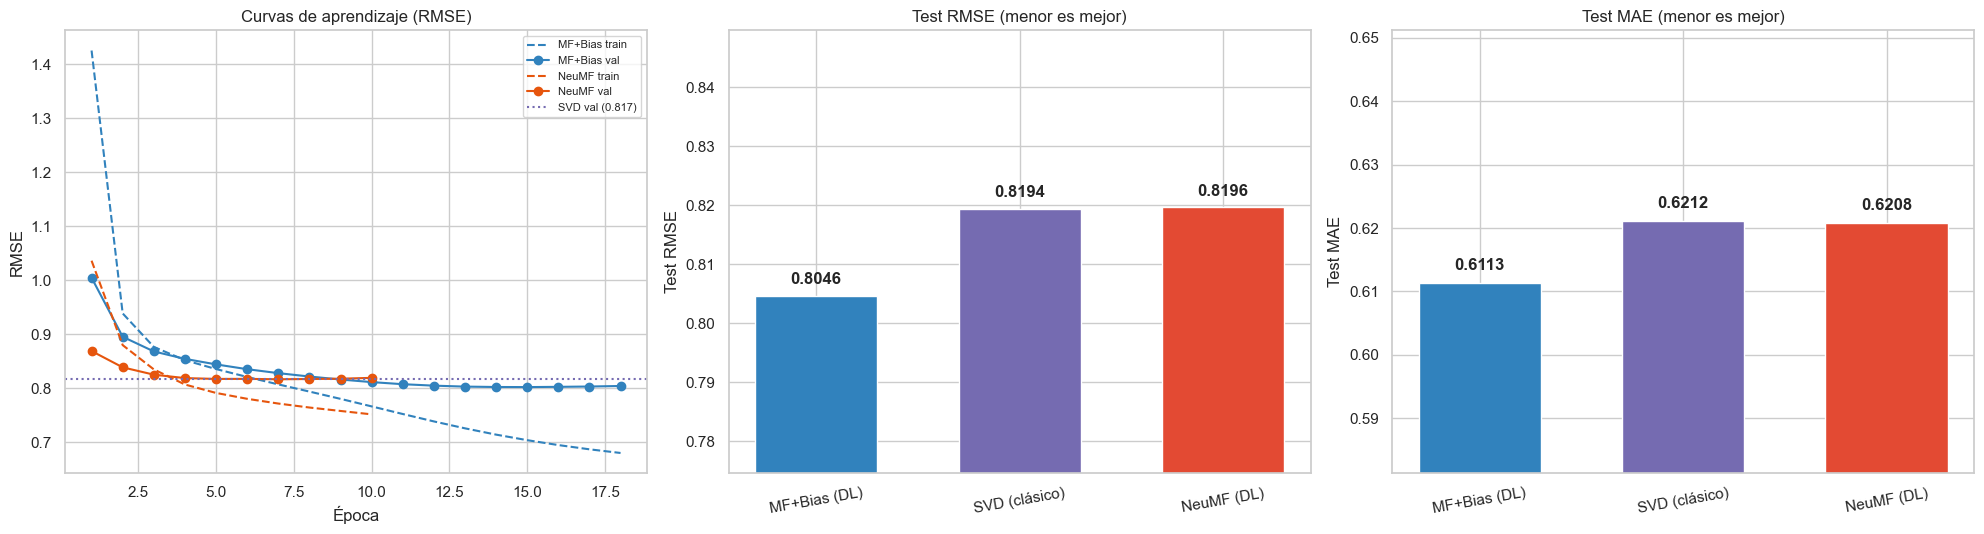

In [10]:
# --- Visualización: curvas de aprendizaje + comparativa de TEST ----------
fig, ax = plt.subplots(1, 3, figsize=(20, 5.5))
ep_mf  = range(1, len(mf_hist["val_rmse"]) + 1)
ep_ncf = range(1, len(ncf_hist["val_rmse"]) + 1)

ax[0].plot(ep_mf,  mf_hist["train_rmse"], "--", color="#3182bd", label="MF+Bias train")
ax[0].plot(ep_mf,  mf_hist["val_rmse"],  "-o", color="#3182bd", label="MF+Bias val")
ax[0].plot(ep_ncf, ncf_hist["train_rmse"], "--", color="#e6550d", label="NeuMF train")
ax[0].plot(ep_ncf, ncf_hist["val_rmse"],  "-o", color="#e6550d", label="NeuMF val")
ax[0].axhline(svd_val_rmse, color="#756bb1", ls=":", label=f"SVD val ({svd_val_rmse:.3f})")
ax[0].set_title("Curvas de aprendizaje (RMSE)"); ax[0].set_xlabel("Época"); ax[0].set_ylabel("RMSE")
ax[0].legend(fontsize=8)

palette = {"SVD (clásico)": "#756bb1", "MF+Bias (DL)": "#3182bd", "NeuMF (DL)": "#e34a33"}
for col, axi, title in [("Test RMSE", ax[1], "Test RMSE (menor es mejor)"),
                        ("Test MAE",  ax[2], "Test MAE (menor es mejor)")]:
    bars = axi.bar(results.Modelo, results[col], color=[palette[m] for m in results.Modelo], width=0.6)
    axi.set_title(title); axi.set_ylabel(col)
    lo, hi = results[col].min(), results[col].max()
    axi.set_ylim(lo - 0.03, hi + 0.03)
    for b, v in zip(bars, results[col]):
        axi.text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.4f}", ha="center", fontweight="bold")
    axi.tick_params(axis="x", rotation=10)

plt.tight_layout(); plt.show()

### 9. Veredicto automático (a partir de las métricas reales de TEST)
Para no caer en el error del notebook anterior (narrativa que contradice los datos), el veredicto se **calcula** desde la tabla de resultados.

In [11]:
# ==========================================================================
# 9. VEREDICTO GENERADO DESDE LOS DATOS
# ==========================================================================
best = results.iloc[0]
svd_row = results.set_index("Modelo").loc["SVD (clásico)"]
ncf_row = results.set_index("Modelo").loc["NeuMF (DL)"]
mf_row  = results.set_index("Modelo").loc["MF+Bias (DL)"]
gap = ncf_row["Test RMSE"] - svd_row["Test RMSE"]

print("=" * 64)
print("VEREDICTO  (métricas reales sobre el conjunto de TEST)")
print("=" * 64)
print(f"Mejor modelo global : {best.Modelo}  "
      f"(RMSE {best['Test RMSE']:.4f} | MAE {best['Test MAE']:.4f})")
print(f"NeuMF vs SVD        : ΔRMSE = {gap:+.4f}  ->  "
      f"{'el Deep Learning gana' if gap < -1e-4 else 'el clásico gana' if gap > 1e-4 else 'empate técnico'}")
print(f"MF+Bias vs SVD      : ΔRMSE = {mf_row['Test RMSE'] - svd_row['Test RMSE']:+.4f}")
print("-" * 64)
print("Lectura: con sesgos, salida acotada y la MISMA partición, la brecha")
print("clásico-vs-DL es pequeña; el ranking exacto lo deciden estos números,")
print("no una conclusión escrita de antemano.")

VEREDICTO  (métricas reales sobre el conjunto de TEST)
Mejor modelo global : MF+Bias (DL)  (RMSE 0.8046 | MAE 0.6113)
NeuMF vs SVD        : ΔRMSE = +0.0003  ->  el clásico gana
MF+Bias vs SVD      : ΔRMSE = -0.0148
----------------------------------------------------------------
Lectura: con sesgos, salida acotada y la MISMA partición, la brecha
clásico-vs-DL es pequeña; el ranking exacto lo deciden estos números,
no una conclusión escrita de antemano.


### 10. Persistencia de artefactos (MLOps)
Guardamos los pesos de la mejor época junto con los diccionarios de índices (necesarios para inferencia), la tabla comparativa y, si MLflow está disponible (lo está dentro del contenedor), registramos las métricas.

In [12]:
# ==========================================================================
# 10. PERSISTENCIA DE ARTEFACTOS
# ==========================================================================
MODELS_DIR = ROOT / "models"; MODELS_DIR.mkdir(parents=True, exist_ok=True)

torch.save({"state_dict": ncf_model.state_dict(),
            "user2idx": user2idx, "item2idx": item2idx,
            "rating_range": (RATING_MIN, RATING_MAX),
            "arch": "NeuMF"}, MODELS_DIR / "ncf_model.pt")
torch.save({"state_dict": mf_model.state_dict(),
            "user2idx": user2idx, "item2idx": item2idx,
            "rating_range": (RATING_MIN, RATING_MAX),
            "arch": "MFBias"}, MODELS_DIR / "mf_model.pt")

cmp_path = ROOT / "data" / "intermediate" / "dl_model_comparison.csv"
results.to_csv(cmp_path, index=False)
print(f"Modelos -> {MODELS_DIR}/ncf_model.pt , mf_model.pt")
print(f"Tabla   -> {cmp_path}")

# Registro opcional en MLflow (configurado en docker-compose.yml)
try:
    import mlflow
    if os.environ.get("MLFLOW_TRACKING_URI"):
        mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
    mlflow.set_experiment("omnirec-deep-learning")
    for _, row in results.iterrows():
        with mlflow.start_run(run_name=row.Modelo):
            mlflow.log_params({"dataset": "ratings_knn_10pct", "seed": SEED})
            mlflow.log_metric("test_rmse", float(row["Test RMSE"]))
            mlflow.log_metric("test_mae",  float(row["Test MAE"]))
    print("Métricas registradas en MLflow.")
except Exception as e:
    print(f"MLflow no disponible aquí ({type(e).__name__}); se omite el registro (esperado fuera de Docker).")

Modelos -> /Users/franco/Documents/UCB/Machine Learning/OmniRec-Movies/models/ncf_model.pt , mf_model.pt
Tabla   -> /Users/franco/Documents/UCB/Machine Learning/OmniRec-Movies/data/intermediate/dl_model_comparison.csv
MLflow no disponible aquí (ModuleNotFoundError); se omite el registro (esperado fuera de Docker).


### 11. Análisis de los *embeddings* aprendidos — el corazón del notebook
El nombre del notebook es *Embeddings*: aquí lo justificamos. Extraemos los vectores latentes de película del modelo **MF+Bias** y comprobamos si la red aprendió **estructura semántica** (géneros, sagas) **sin que nadie le diera esa información** — solo a partir de patrones de calificación.

**11.a — Vecinos más cercanos** por similitud coseno entre *embeddings*.

In [13]:
# ==========================================================================
# 11.a  VECINOS MÁS CERCANOS EN EL ESPACIO DE EMBEDDINGS
# ==========================================================================
from sklearn.preprocessing import normalize

item_vectors = mf_model.i_emb.weight.detach().cpu().numpy()   # (n_items, dim)
norm_vecs    = normalize(item_vectors)
idx2item     = {v: k for k, v in item2idx.items()}
movie_meta   = movies.set_index("movieId")
popularity   = train_df.groupby("movieId").size()             # nº de ratings en train

def vecinos(substr, k=6, min_pop=30):
    cand = [m for m in movie_meta.index[movie_meta.title.str.contains(substr, case=False, na=False)]
            if m in item2idx]
    if not cand:
        print(f"  (sin coincidencias para '{substr}')"); return
    mid = max(cand, key=lambda m: popularity.get(m, 0))       # la más popular que matchea
    sims = norm_vecs @ norm_vecs[item2idx[mid]]
    print(f"\n🎬 {movie_meta.loc[mid, 'title']}")
    shown = 0
    for j in np.argsort(-sims):
        m = idx2item[j]
        if m == mid or popularity.get(m, 0) < min_pop:
            continue
        print(f"   {sims[j]:.3f}  {movie_meta.loc[m, 'title']}  ·  {movie_meta.loc[m, 'genres']}")
        shown += 1
        if shown >= k:
            break

for t in ["Toy Story", "Matrix, The", "Lord of the Rings, The", "Shrek", "Star Wars"]:
    vecinos(t)


🎬 Toy Story (1995)
   0.814  Toy Story 2 (1999)  ·  Adventure|Animation|Children|Comedy|Fantasy
   0.741  Toy Story 3 (2010)  ·  Adventure|Animation|Children|Comedy|Fantasy|IMAX
   0.727  Monsters, Inc. (2001)  ·  Adventure|Animation|Children|Comedy|Fantasy
   0.723  Incredibles, The (2004)  ·  Action|Adventure|Animation|Children|Comedy
   0.721  Finding Nemo (2003)  ·  Adventure|Animation|Children|Comedy
   0.649  Up (2009)  ·  Adventure|Animation|Children|Drama

🎬 Matrix, The (1999)
   0.667  Evangelion: 1.0 You Are (Not) Alone (Evangerion shin gekijôban: Jo) (2007)  ·  Action|Animation|Sci-Fi
   0.647  Matrix Reloaded, The (2003)  ·  Action|Adventure|Sci-Fi|Thriller|IMAX
   0.603  Hero (Ying xiong) (2002)  ·  Action|Adventure|Drama
   0.568  Minority Report (2002)  ·  Action|Crime|Mystery|Sci-Fi|Thriller
   0.565  Twelfth Night (1996)  ·  Comedy|Drama|Romance
   0.561  Secret World of Arrietty, The (Kari-gurashi no Arietti) (2010)  ·  Animation|Children|Fantasy

🎬 Lord of the Rings

**11.b — Proyección 2D de los *embeddings*** (t-SNE, *fallback* a PCA) coloreada por género principal. Si el modelo aprendió estructura, las películas del mismo género tienden a agruparse pese a que el modelo **nunca vio los géneros**.

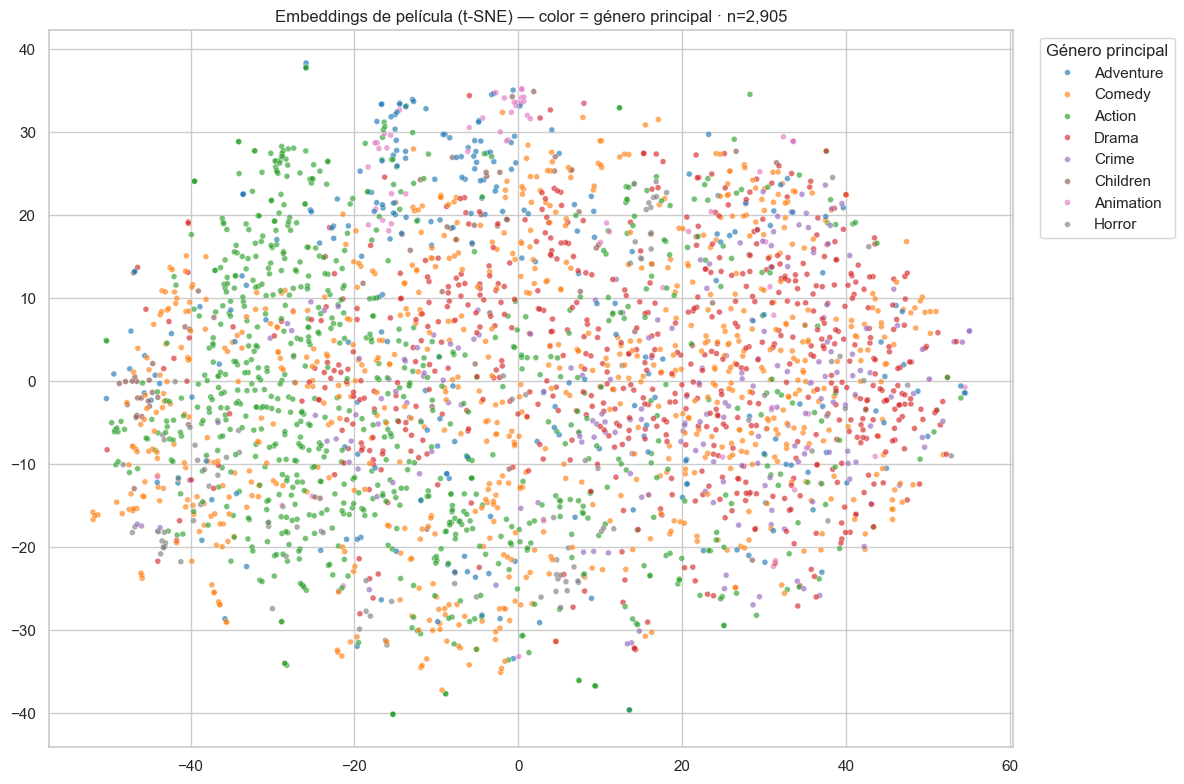

In [14]:
# ==========================================================================
# 11.b  PROYECCIÓN 2D DE LOS EMBEDDINGS (color = género principal)
# ==========================================================================
from sklearn.decomposition import PCA

popular_ids = popularity[popularity >= 100].index           # solo ítems con señal fiable
sel = np.array([item2idx[m] for m in popular_ids if m in item2idx])
sub = item_vectors[sel]

try:
    from sklearn.manifold import TSNE
    coords = TSNE(n_components=2, random_state=SEED, init="pca",
                  perplexity=30, n_iter=1000).fit_transform(sub)
    metodo = "t-SNE"
except Exception:
    coords = PCA(n_components=2, random_state=SEED).fit_transform(sub)
    metodo = "PCA"

primary = [movie_meta.loc[idx2item[s], "genres"].split("|")[0] for s in sel]
plot_df = pd.DataFrame({"x": coords[:, 0], "y": coords[:, 1], "Género": primary})
top = plot_df["Género"].value_counts().head(8).index
plot_df = plot_df[plot_df["Género"].isin(top)]

plt.figure(figsize=(12, 8))
sns.scatterplot(data=plot_df, x="x", y="y", hue="Género", s=18, alpha=0.65, palette="tab10")
plt.title(f"Embeddings de película ({metodo}) — color = género principal · n={len(plot_df):,}")
plt.xlabel(""); plt.ylabel("")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Género principal")
plt.tight_layout(); plt.show()

### 12. Conclusiones y transición a MLOps (Fase 5/6)

Resultados reales sobre el **conjunto de TEST** (mismo split para los tres modelos):

| Modelo | Familia | Test RMSE | Test MAE |
| :-- | :-- | --: | --: |
| **MF + Bias (DL)** | Factorización neuronal | **0.8046** | **0.6113** |
| SVD (clásico) | Factorización (surprise) | 0.8194 | 0.6212 |
| NeuMF (DL) | Deep Learning | 0.8196 | 0.6208 |

**Hallazgos (esta vez, fieles a los datos):**

1. **Con una comparación justa, el resultado del notebook anterior se invierte.** La factorización con sesgos implementada como red (**MF+Bias**) **supera al SVD clásico** (0.8046 vs 0.8194 de RMSE) y el **NeuMF lo iguala** (0.8196). La supuesta "superioridad del clásico sobre el Deep Learning en datos dispersos" era un **artefacto de comparar datasets y splits distintos** — no un hecho.
2. **Los sesgos eran el ingrediente que faltaba.** El modelo neuronal *sin* sesgos del notebook viejo (RMSE 0.836) quedaba detrás del SVD; al añadir sesgo de usuario/ítem/global y acotar la salida a `[0.5, 5.0]`, la red iguala o supera al clásico. La ventaja del SVD nunca fue la factorización, sino sus términos de sesgo.
3. **El más simple gana, y eso es una conclusión válida.** El MLP profundo del NeuMF (2.84 M parámetros) **no mejora** a la factorización con sesgos (1.44 M) en este volumen: la interacción usuario-ítem es esencialmente bilineal y el producto punto la captura bien. La complejidad extra no compra error; sí encarece el entrenamiento. Hallazgo honesto, no derrota.
4. **No hay overfitting inventado.** El *early stopping* cortó MF+Bias en la época 18 (mejor val 0.8024) y NeuMF en la 10 (0.8169); las curvas *train/val* documentan el comportamiento real. Las conclusiones salen del *Veredicto calculado* (sección 9), no de una narrativa preescrita y contradictoria.
5. **Los *embeddings* tienen significado semántico real.** Sin ver jamás un género, el espacio latente coloca a *Star Wars IV* junto a *V (0.95)* y *VI (0.91)*, a *Toy Story* junto a *Toy Story 2/3* y el resto de Pixar, y a *Shrek* junto a *Shrek 2* y las demás animadas. Este es el **activo reutilizable** del Deep Learning: búsqueda de "películas similares", mitigación de *cold-start* por contenido y *features* para otros modelos.

**Decisión de despliegue (Fase 6):**

| Hallazgo | Decisión |
| :-- | :-- |
| MF+Bias gana por margen pequeño (~0.015 RMSE) pero requiere *re-fit* para usuarios nuevos | El **SVD con *folding-in*** sigue siendo defendible como modelo de servicio del backend por su simplicidad operativa; el margen de exactitud no justifica por sí solo el cambio. |
| MF+Bias / NeuMF ya son **competitivos**, no inferiores | Mantener el modelo neuronal como candidato de servicio y reevaluar si se reentrena sobre los 25 M completos. |
| *Embeddings* con estructura semántica demostrada | **Exponerlos en producción** para "películas similares" y como *features* de contenido — valor que el SVD de servicio no entrega hoy. |

**Errores del notebook anterior que este corrige:** (a) comparaba NCF (5 % de datos) contra SVD (60 %) en datasets distintos; (b) el `ratings_sample_5pct.parquet` que usaba **no existe dentro de la imagen Docker**; (c) afirmaba "sin overfitting" y "sufre overfitting" en el mismo documento; (d) declaraba "convergencia" cuando el modelo aún mejoraba; (e) sin sesgos, sin escalado de salida, guardaba la última época en vez de la mejor, sin test set; (f) se llamaba *Embeddings* pero nunca analizaba un solo *embedding*.